# Lesson 1.10: Data Visualisation & Storytelling

Lesson 1.8 asked *can I trust this data?* Lesson 1.9 asked *what is the pattern?* You answered both.
You have a table that shows exactly what is happening to the café chain.

This lesson is about the last twenty seconds — the part where the owner either acts on it or doesn't.

**Structure — the four learning outcomes, in order:**
* **Part 1: The Three Pillars** — *apply* perception, design and storytelling to fix a bad chart.
* **Part 2: Matplotlib Fundamentals** — *create* charts with the Figure → Axes → plot hierarchy.
* **Part 3: Seaborn for Statistical Graphics** — *use* the right statistical view for the data type.
* **Part 4: Chart Choice & the One Slide** — *select* the chart your message needs, and build it.

**How to work through this:** read the `# 👉` comment above each line before you run the cell. Charts are the one
topic where you learn most by breaking things on purpose, so several cells here are deliberately bad.


> **🧭 Today's flow — 180 minutes.** One message, four learning outcomes, in order:
>
> | | Section | Learning outcome | Time |
> |---|---|---|---|
> | — | Setup + why this matters | | 5 min |
> | **Part 1** | The Three Pillars | **Apply** perception, design, storytelling | 40 min |
> | ☕ | *Break* | | 10 min |
> | **Part 2** | Matplotlib Fundamentals | **Create** charts: Figure → Axes → plot | 45 min |
> | ☕ | *Break* | | 10 min |
> | **Part 3** | Seaborn | **Use** statistical graphics for the data type | 45 min |
> | **Part 4** | Chart Choice & the One Slide | **Select** the chart the message needs | 25 min |
>
> **The spine:** the same business problem as 1.9 — *The Daily Grind* café chain — and the same
> files. You already know the answer. Today you make it land.
>
> Each of Parts 1–3 ends with a **🛠️ Group Exercise**. Deep dives (colour theory, accessibility,
> Gestalt, the research behind pre-attentive processing) live in `reference.md`.


### The one rule this lesson is built on

> **The chart is chosen by the message, not by taste.**

Write the sentence you want the audience to leave with, in words, first. The chart type follows from
that sentence almost mechanically. Every mistake in Part 1 comes from doing it the other way round —
picking a chart, then hunting for something to say.


### Setup


In [14]:
# 👉 pandas for the data, matplotlib for drawing, seaborn for statistical charts.
#    `plt` and `sns` are the conventional nicknames -- you will see them in every tutorial.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 👉 Housekeeping only: keep version-deprecation notices out of our output.
import warnings
warnings.filterwarnings("ignore")

# 👉 Draw charts underneath the cell that made them, inside the notebook.
%matplotlib inline


In [15]:
# 👉 The same café data as Lesson 1.9, plus the decision table you produced at the end of it.
sales = pd.read_csv("../data/daily_sales.csv", parse_dates=["date"])
outlets = pd.read_csv("../data/outlets.csv", parse_dates=["opened_date"])
tickets = pd.read_csv("../data/tickets_week.csv", parse_dates=["txn_datetime"])
decision = pd.read_csv("../data/lesson19_decision.csv", index_col="outlet_id")

decision.round(1)


,outlet_name,rev_2025_h1,change_pct,rent_pct_of_revenue,rev_per_staff_hour
outlet_id,,,,,
OUT-03,Marina Bay,203147.5,-27.9,28.4,19.9
OUT-01,Raffles Place,309339.2,-1.5,15.9,26.4
OUT-02,Tampines Mall,279272.0,1.3,14.6,25.5
OUT-04,Holland Village,253450.1,26.5,14.7,26.7
OUT-05,NaN,61309.5,NaN,NaN,26.0


In [16]:
# 👉 Two summaries we will chart all session. Both are straight out of Lesson 1.9.
#    (1) monthly revenue per outlet -- one column per outlet, dates on the index.
monthly = sales.pivot_table(
    index="date", columns="outlet_id", values="revenue_sgd", aggfunc="sum"
).resample("M").sum()

# 👉 (2) revenue by outlet and daypart.
by_daypart = sales.pivot_table(
    index="outlet_id", columns="daypart", values="revenue_sgd", aggfunc="sum"
)[["Morning", "Midday", "Evening"]]

# 👉 Friendly names, for chart labels. Codes belong in databases, not on slides.
names = outlets.set_index("outlet_id")["outlet_name"].to_dict()

monthly.tail(5).round(0)

# by_daypart.round(0)


outlet_id,OUT-01,OUT-02,OUT-03,OUT-04,OUT-05
date,,,,,
2025-02-28,47764.0,42186.0,32165.0,38456.0,0.0
2025-03-31,50549.0,48397.0,34927.0,45970.0,20493.0
2025-04-30,53250.0,47146.0,33777.0,41892.0,19595.0
2025-05-31,52570.0,50158.0,33822.0,44123.0,21221.0
2025-06-30,53255.0,44896.0,32818.0,44700.0,0.0


### 🎬 Why this matters — the same finding, three ways

**The situation.** You have five minutes at the end of a Monday meeting. The owner is deciding
whether to renew the Marina Bay lease. You already know the answer: chain revenue is flat because
Marina Bay is falling and Holland Village is rising, and Marina Bay's fall is a step dated to the
first week of November 2024.

Below is that finding presented three ways. Same data. Same truth. Run all three, then decide which
one makes somebody *do* something.


In [17]:
# 👉 Version 1: the numbers. Complete, precise, and almost impossible to read at speed.
monthly.round(0).tail(12)


outlet_id,OUT-01,OUT-02,OUT-03,OUT-04,OUT-05
date,,,,,
2024-07-31,55315.0,48409.0,48581.0,36779.0,0.0
2024-08-31,52530.0,48299.0,47079.0,38089.0,0.0
2024-09-30,50083.0,45214.0,43679.0,36634.0,0.0
2024-10-31,54212.0,44320.0,46138.0,37368.0,0.0
2024-11-30,48362.0,45761.0,35344.0,37488.0,0.0
2024-12-31,51839.0,46734.0,33956.0,39548.0,0.0
2025-01-31,51951.0,46489.0,35638.0,38309.0,0.0
2025-02-28,47764.0,42186.0,32165.0,38456.0,0.0
2025-03-31,50549.0,48397.0,34927.0,45970.0,20493.0


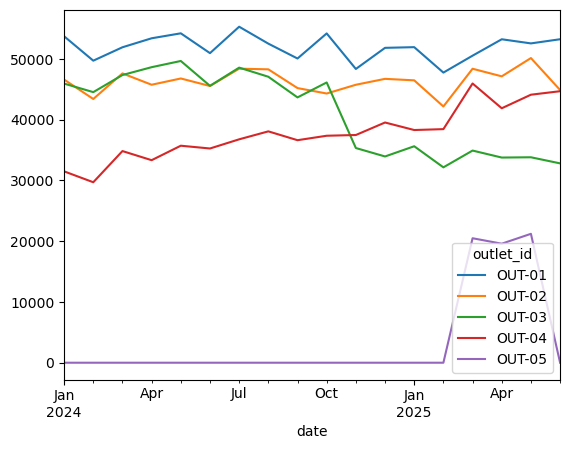

In [18]:
# 👉 Version 2: a chart, made without thinking. Every default left as it came.
monthly.plot()
plt.show()


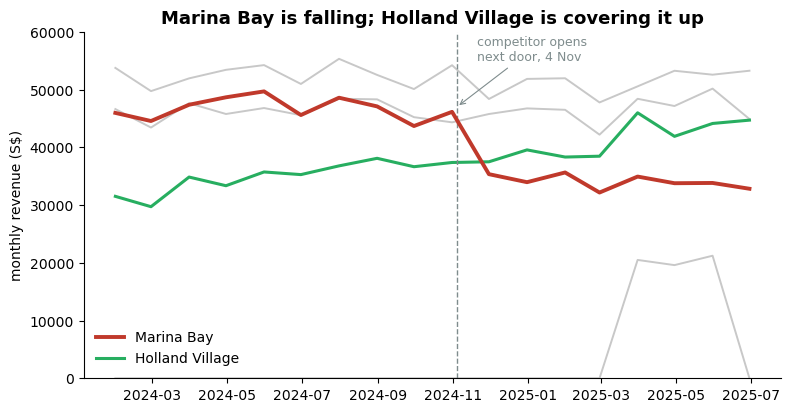

In [19]:
# 👉 Version 3: the same numbers, drawn to make one point. Read the code later --
#    for now just compare what your eye does with this versus the two above.
# color codes: https://htmlcolorcodes.com/color-names/

fig, ax = plt.subplots(figsize=(9, 4.5))

for col in monthly.columns:
    if col == "OUT-03":
        ax.plot(monthly.index, monthly[col], color="#c0392b", linewidth=2.8, label="Marina Bay", zorder=3) # zorder controls which lines are drawn on top of which others, 3 is the highest here
    elif col == "OUT-04":
        ax.plot(monthly.index, monthly[col], color="#27ae60", linewidth=2.2, label="Holland Village", zorder=2)
    else:
        ax.plot(monthly.index, monthly[col], color="#c8c8c8", linewidth=1.4, zorder=1)

ax.axvline(pd.Timestamp("2024-11-04"), color="#7f8c8d", linestyle="--", linewidth=1)
ax.annotate("competitor opens\nnext door, 4 Nov",
            xy=(pd.Timestamp("2024-11-04"), 47000), xytext=(pd.Timestamp("2024-11-20"), 55000),
            fontsize=9, color="#7f8c8d",
            arrowprops=dict(arrowstyle="->", color="#7f8c8d", linewidth=0.8))

ax.set_title("Marina Bay is falling; Holland Village is covering it up", fontsize=13, weight="bold")
ax.set_ylabel("monthly revenue (S$)")
ax.set_ylim(0, 60000)
ax.legend(frameon=False, loc="lower left") # remove the box around the legend
ax.spines[["top", "right"]].set_visible(False) # remove the top and right borders
plt.show()


**What changed between versions 2 and 3?** Nothing about the data. Four things about the drawing:

1. **One sentence as the title.** Not "Monthly Revenue" — the actual finding, in words.
2. **Colour used as an argument.** Two lines carry the point; the other three went grey. Your eye
   found the red line before you consciously read anything. That reflex is *pre-attentive processing*,
   and it fires in 200 to 500 milliseconds. Charts either use it or waste it.
3. **The cause annotated on the chart.** The reader does not have to be told separately.
4. **Clutter removed.** Two spines gone, no box round the legend, no chart junk competing for attention.

That is the whole lesson: **perception** (how eyes work), **design** (honest, uncluttered choices),
**storytelling** (one message, stated). Everything else is syntax.


---

## Part 1: The Three Pillars

**Learning outcome 1:** *Apply the three storytelling pillars (Perception, Design, Storytelling) to
evaluate and improve visualisations.*

**Goal:** take a genuinely bad chart and fix it in five moves, saying which pillar each move serves.

⏱️ ~40 min including Group Exercise 1


### 1.1: Pillar 1 — Perception: what the eye does before you think

Two facts about human vision do most of the work in chart design:

| Fact | What it means for you |
|---|---|
| **Pre-attentive processing** — colour, length and position register in ~200ms, before conscious attention | one contrasting element is found instantly; ten are found never |
| **Working memory holds about four things** | every extra colour, line or label spends a limited budget |

Length along a common baseline is the most accurately judged visual channel; angle and area are among
the worst. That single ranking is why bar charts beat pie charts, and why nothing good ever came of a
3D exploding donut.


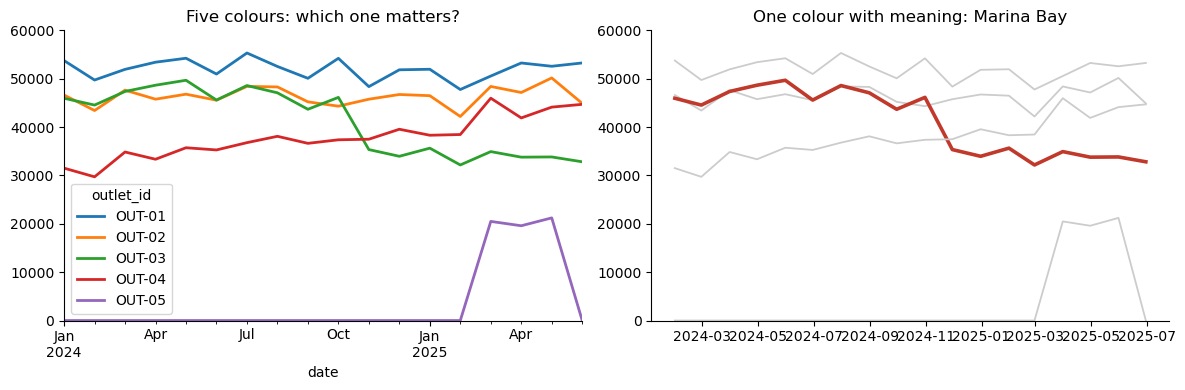

In [20]:
# 👉 Proof, on data you know. Left: five colours, everything shouting. Right: one red, four greys.
#    Ask yourself how long each takes to answer "which outlet is falling?"
fig, axes = plt.subplots(1, 2, figsize=(12, 4)) # 1 row, 2 columns of charts

# Left: five colours, everything shouting
monthly.plot(ax=axes[0], linewidth=2)
axes[0].set_title("Five colours: which one matters?") 

# Right: one red, four greys
for col in monthly.columns:
    highlight = col == "OUT-03"
    axes[1].plot(monthly.index, monthly[col],
                 color="#c0392b" if highlight else "#cccccc",
                 linewidth=2.6 if highlight else 1.3)
axes[1].set_title("One colour with meaning: Marina Bay")

for ax in axes:
    ax.set_ylim(0, 60000)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout() # adjust the spacing between the two charts so titles don't overlap
plt.show() # display the charts


> **The grey is not decoration.** The four grey lines still supply the context that makes the red one
> meaningful — without them you cannot see that the others are steady. Grey is how you keep context
> without spending attention on it.


### 1.2: Pillar 2 — Design: the same numbers, honest and not

Design is mostly about *not lying*. The most common lie in business reporting is the truncated axis.

Further reading: https://medium.com/@Ana_kin/graphs-gone-wrong-misleading-data-visualizations-d4805d1c4700


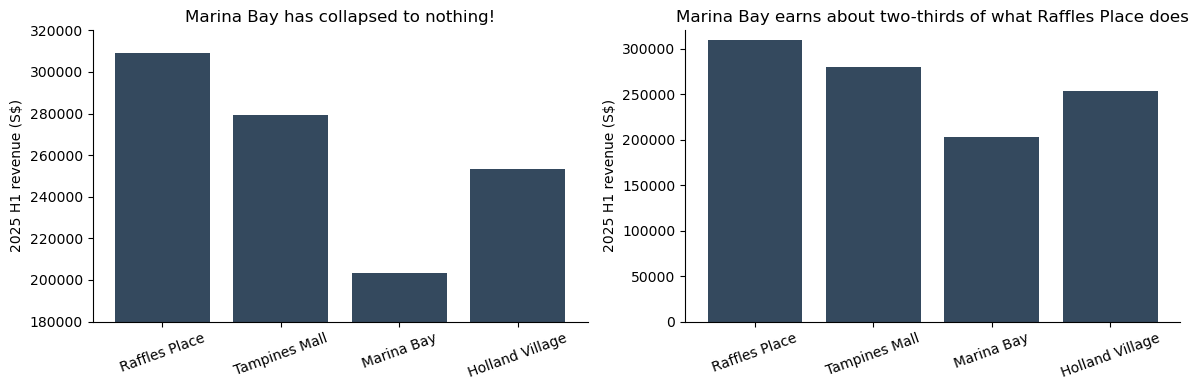

In [21]:
# 👉 Both panels plot the same four numbers: 2025 H1 revenue per outlet.
#    The only difference is where the y-axis starts.
h1 = decision.loc[["OUT-01", "OUT-02", "OUT-03", "OUT-04"], "rev_2025_h1"]
labels = [names[i] for i in h1.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(labels, h1, color="#34495e")
axes[0].set_ylim(180000, 320000)          # 👈 the lie: axis starts at 180,000
axes[0].set_title("Marina Bay has collapsed to nothing!")

axes[1].bar(labels, h1, color="#34495e")
axes[1].set_ylim(0, 320000)               # 👈 the truth: bars start at zero
axes[1].set_title("Marina Bay earns about two-thirds of what Raffles Place does")

for ax in axes:
    ax.set_ylabel("2025 H1 revenue (S$)")
    ax.tick_params(axis="x", labelrotation=20)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


> **Why this one rule matters more than the others.** A bar chart encodes value as **length**. If the
> axis does not start at zero, the length is no longer proportional to the value, and the reader's
> eye is doing arithmetic on a false premise. In the left panel Marina Bay looks like it earns
> perhaps a tenth of what Raffles Place earns. It earns 66% of it.
>
> **Line charts are different.** They encode *position* and are read for *change*, so a truncated
> axis is often the right choice — it lets you see a 3% move that would be invisible on a
> zero-based axis. Rule: **bars start at zero; lines start wherever the change is legible.**


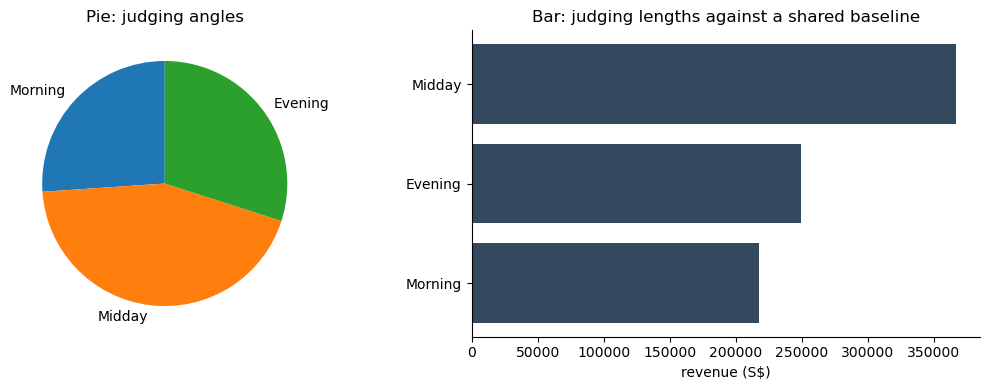

In [22]:
# 👉 Second design trap: the pie chart. Same data, twice. Which is the second-biggest daypart
#    for Tampines Mall? Time yourself on the left, then on the right.
tampines = by_daypart.loc["OUT-02"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].pie(tampines, labels=tampines.index, startangle=90)
axes[0].set_title("Pie: judging angles")

tampines_sorted = tampines.sort_values()  # ascending so barh puts largest on top
axes[1].barh(tampines_sorted.index, tampines_sorted.values, color="#34495e")
axes[1].set_title("Bar: judging lengths against a shared baseline")
axes[1].set_xlabel("revenue (S$)")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


> Pie charts are not banned — for "roughly half versus roughly a quarter", with two or three slices,
> they are fine and familiar. They fail when the shares are close, or when there are more than about
> four of them, because comparing angles is something human vision is measurably bad at.


### 1.3: Pillar 3 — Storytelling: fix a bad chart in five moves

Here is a chart that is not *wrong*. It is just useless. Run it, then we fix it one move at a time,
naming the pillar each move serves.


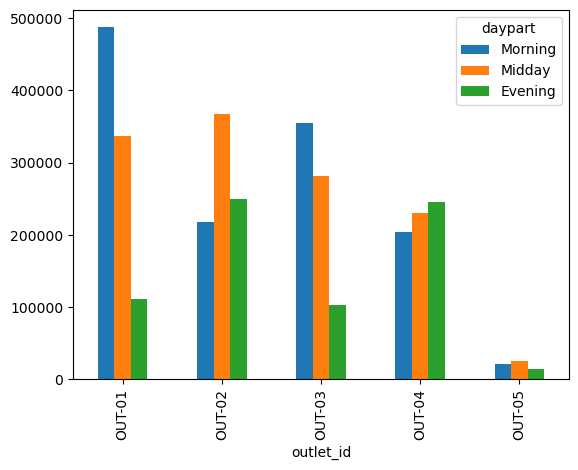

In [23]:
# 👉 The "before". Every default accepted, no thought applied.
by_daypart.plot(kind="bar")
plt.show()


**What is wrong with it?** List everything you can find before reading on.

- The x labels are outlet *codes*, so the reader has to translate.
- Nothing says what the chart is for. "What am I looking at?" has no answer.
- Absolute dollars, so the two biggest outlets dominate and the *pattern* is invisible.
- The legend order (Morning, Midday, Evening) is accidental, not chosen.
- No axis units. Are those dollars? Thousands? Tickets?


In [24]:
# 👉 Move 1 (design): change the numbers to answer the actual question.
#    We care about the MIX, not the size, so convert each row to percentages of itself.
mix = (by_daypart.div(by_daypart.sum(axis=1), axis=0) * 100).round(1)

mix


daypart,Morning,Midday,Evening
outlet_id,,,
OUT-01,52.1,36.0,11.9
OUT-02,26.1,44.0,29.9
OUT-03,48.0,38.0,13.9
OUT-04,30.0,34.0,36.1
OUT-05,33.9,42.4,23.7


In [25]:
# 👉 Move 2 (perception): drop the pop-up kiosk -- it closed, and it is not part of the question.
#    Move 3 (design): real names instead of codes.
mix4 = mix.drop(index="OUT-05")
mix4.index = [names[i] for i in mix4.index]

mix4


daypart,Morning,Midday,Evening
Raffles Place,52.1,36.0,11.9
Tampines Mall,26.1,44.0,29.9
Marina Bay,48.0,38.0,13.9
Holland Village,30.0,34.0,36.1


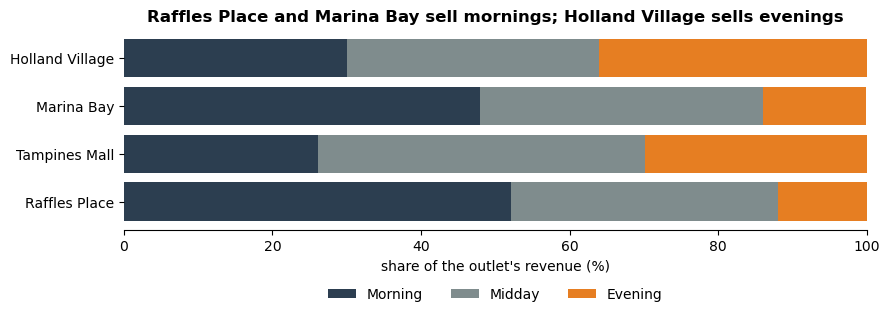

In [26]:
# 👉 Moves 4 and 5, both storytelling: a title that states the finding, and a horizontal
#    stacked bar so the three shares of each outlet read as one 100% row.
fig, ax = plt.subplots(figsize=(9, 3.6))

left = np.zeros(len(mix4))
colours = {"Morning": "#2c3e50", "Midday": "#7f8c8d", "Evening": "#e67e22"}

for part in ["Morning", "Midday", "Evening"]:
    ax.barh(mix4.index, mix4[part], left=left, color=colours[part], label=part)
    left += mix4[part].values

ax.set_title("Raffles Place and Marina Bay sell mornings; Holland Village sells evenings",
             fontsize=12, weight="bold")
ax.set_xlabel("share of the outlet's revenue (%)")
ax.set_xlim(0, 100)
ax.legend(frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.42))
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
plt.show()


**The five moves, and the pillar each one served:**

| Move | Pillar | Why |
|---|---|---|
| 1. Percentages, not dollars | Design | matches the number to the question (mix, not size) |
| 2. Removed the kiosk | Perception | one fewer thing competing for a four-item memory budget |
| 3. Real names | Perception | no mental translation step |
| 4. Title states the finding | Storytelling | the reader gets the message even if they read nothing else |
| 5. Stacked horizontal bars | Design | each row is one 100% whole; long labels fit horizontally |

**Nothing about the data changed.** The chart went from useless to actionable purely through
presentation choices — and every choice traces back to one of the three pillars.


### 🛠️ Group Exercise 1 — Critique and fix (10 min)

> **(a) Worked for you** — the cell below is the bad chart with just *one* fix applied (real names).
> Run it, and say what is still wrong.
>
> **(b) Critique, no code** — take the chart from (a) and list every remaining problem. Aim for four.
> Beside each, write which pillar it violates: Perception, Design or Storytelling.
>
> **(c) Fill in the blanks** — a bar chart of `rent_pct_of_revenue`, with Marina Bay in red and the
> rest grey:
> ```python
> r = decision["rent_pct_of_revenue"].dropna().sort_values()
> colours = ["#c0392b" if i == "______" else "#cccccc" for i in r.index]
> fig, ax = plt.subplots()
> ax.barh([names[i] for i in r.index], r.values, color=______)
> ax.set_ylim(____)   # careful -- is a y-limit even the right thing for a horizontal bar chart?
> ```
> *Expected:* Marina Bay's bar is roughly twice everyone else's. Note that for `barh` it is the
> **x**-axis that carries the value, so `set_xlim(0, ...)` is the zero-baseline rule here.
>
> **(d) Argue it out** — one member of your group must argue *for* using a truncated axis on a bar
> chart. When, if ever, is it defensible? (There is a real answer, and it involves labelling.)


**(a) Worked example** — one fix applied, several problems remaining:


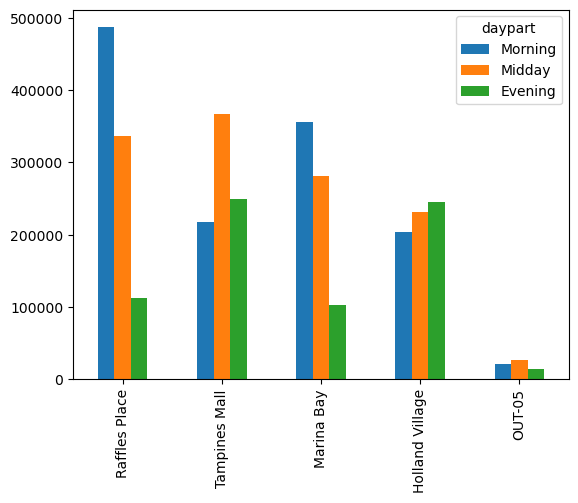

In [27]:
# 👉 Only change from the "before" chart: outlet codes replaced with names.
renamed = by_daypart.copy()
renamed.index = [names.get(i, i) for i in renamed.index]

renamed.plot(kind="bar")
plt.show()


---

# ☕ Break — 10 minutes

**Where we are:** you can look at a chart and say what is wrong with it, and why, in the language of
the three pillars.

**Next up:** Part 2 — how matplotlib actually works, so you can build any of it yourself instead of
accepting `.plot()`'s defaults.


## Part 2: Matplotlib Fundamentals

**Learning outcome 2:** *Create charts using Matplotlib's Figure-Axes-Plot hierarchy with proper
customisation.*

**Goal:** stop fighting the defaults. Once the hierarchy clicks, every tutorial you read afterwards
makes sense.

⏱️ ~45 min including Group Exercise 2


### 2.1: Figure, Axes, plot — the whole mental model

Three levels, and almost every error comes from confusing them:

| Level | What it is | The analogy |
|---|---|---|
| **Figure** | the whole image, the thing you save | the sheet of paper |
| **Axes** | one set of x and y axes — one panel | a chart drawn on the paper |
| **plot / artists** | the marks: lines, bars, text | the ink |

A Figure can hold many Axes. `plt.subplots()` creates both at once, and returns them in that order:
`fig, ax = plt.subplots()`. **Learn that line.** Everything else hangs off `ax`.


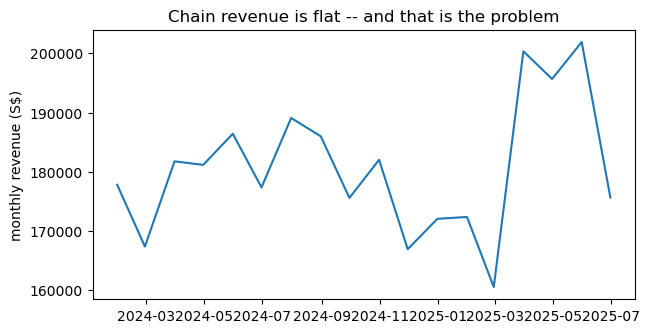

In [28]:
# 👉 The canonical opening line: one Figure, one Axes. `figsize` is in inches (width, height). 
fig, ax = plt.subplots(figsize=(7, 3.5))

# 👉 `ax.plot(x, y)` draws a line on that Axes. Here: chain revenue per month.
chain = monthly.sum(axis=1)
ax.plot(chain.index, chain.values)

# 👉 Everything descriptive is a method on `ax`. Same pattern for all of them.
ax.set_title("Chain revenue is flat -- and that is the problem")
ax.set_ylabel("monthly revenue (S$)")

plt.show()


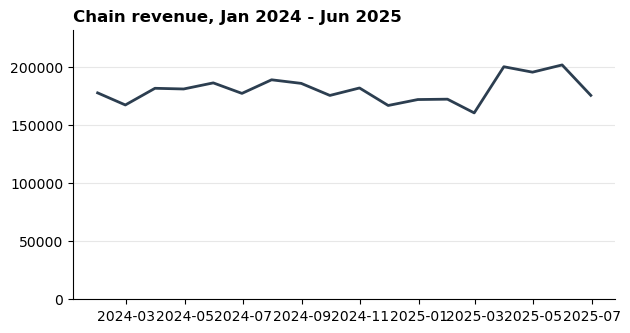

In [29]:
# 👉 `ax` also has the styling controls. Four habits worth using every time:
fig, ax = plt.subplots(figsize=(7, 3.5))

ax.plot(chain.index, chain.values, color="#2c3e50", linewidth=2)

ax.set_ylim(0, chain.max() * 1.15)                      # 1. include zero for magnitude
ax.spines[["top", "right"]].set_visible(False)          # 2. remove the box
ax.grid(axis="y", alpha=0.3)                            # 3. faint horizontal guides only
ax.set_title("Chain revenue, Jan 2024 - Jun 2025", loc="left", weight="bold")   # 4. title left

plt.show()


> **`plt.something()` versus `ax.something()`.** The `plt.` functions act on "the current chart",
> which is fine for one panel and a menace with several. `ax.` is explicit about *which* panel.
> Use the `fig, ax = plt.subplots()` style from the start and you will never debug this.


### 2.2: Subplots — several Axes on one Figure

Small multiples are the most underrated chart type in business reporting: the same chart repeated per
group, on identical axes, so differences in *shape* are obvious.


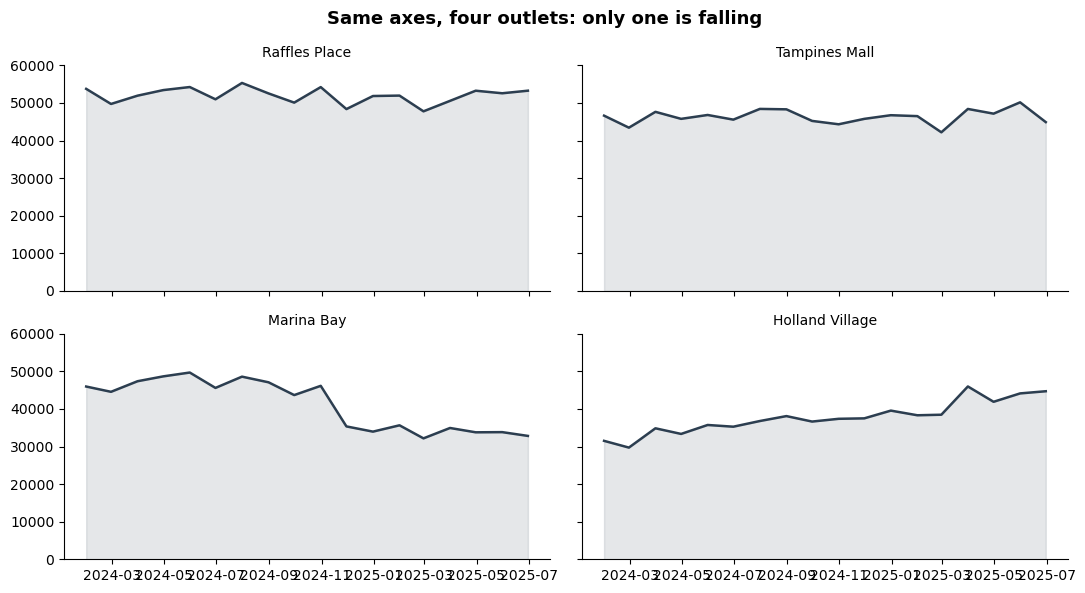

In [30]:
# 👉 A 2x2 grid. `axes` comes back as a NumPy array of Axes, so `.flatten()` lets us loop over it.
#    `sharey=True` forces one scale on all four -- essential, or the panels lie by comparison.
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True, sharey=True)

for ax, outlet in zip(axes.flatten(), ["OUT-01", "OUT-02", "OUT-03", "OUT-04"]):
    ax.plot(monthly.index, monthly[outlet], color="#2c3e50", linewidth=1.8)
    ax.fill_between(monthly.index, monthly[outlet], color="#2c3e50", alpha=0.12)
    ax.set_title(names[outlet], fontsize=10)
    ax.set_ylim(0, 60000)
    ax.spines[["top", "right"]].set_visible(False)

# 👉 One title for the whole Figure -- note it is `fig`, not `ax`.
fig.suptitle("Same axes, four outlets: only one is falling", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()


> **`sharey=True` is doing the ethical work here.** Without it, matplotlib scales each panel to its
> own data and Holland Village's \$45k month looks the same height as Raffles Place's \$55k month.
> Small multiples without a shared scale are one of the easiest ways to mislead by accident.


### 2.3: Ticks, limits and labels

Axis text is not decoration — it is most of what makes a chart readable at a glance.


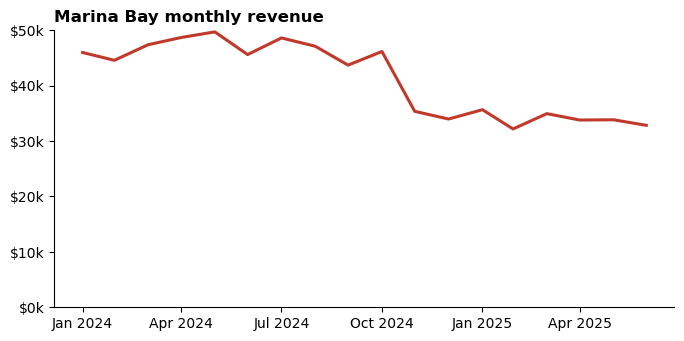

In [31]:
# 👉 Two fixes that pay for themselves on every chart you make:
#    1. thousands separators on the money axis, so nobody counts digits
#    2. horizontal date labels, by using fewer of them
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(monthly.index, monthly["OUT-03"], color="#c0392b", linewidth=2.2)

# 👉 A formatter takes the raw tick value and returns the text to print.
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v/1000:,.0f}k"))

ax.set_xticks(monthly.index[::3])                          # every third month only
ax.set_xticklabels([d.strftime("%b %Y") for d in monthly.index[::3]])

ax.set_ylim(0, 50000)
ax.set_title("Marina Bay monthly revenue", loc="left", weight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.show()


### 2.4: Annotation — putting the sentence on the chart

An annotated chart survives being forwarded without you attached to it. This is the single highest-value
matplotlib skill in a business setting.


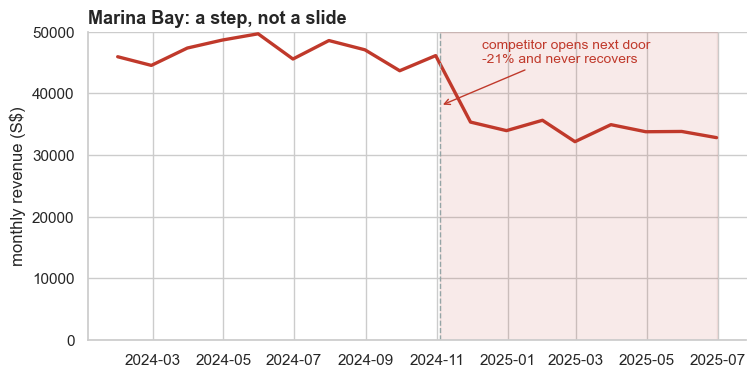

In [53]:
# 👉 `axvline` draws a vertical rule; `annotate` places text with an optional arrow.
#    `xy` is what you are pointing AT; `xytext` is where the words sit.
fig, ax = plt.subplots(figsize=(8.5, 4))

ax.plot(monthly.index, monthly["OUT-03"], color="#c0392b", linewidth=2.4)
ax.axvline(pd.Timestamp("2024-11-04"), color="#95a5a6", linestyle="--", linewidth=1) # vertical rule

ax.annotate("competitor opens next door\n-21% and never recovers",
            xy=(pd.Timestamp("2024-11-04"), 38000),
            xytext=(pd.Timestamp("2024-12-10"), 45000),
            fontsize=10, color="#c0392b",
            arrowprops=dict(arrowstyle="->", color="#c0392b", linewidth=1))

# 👉 Shade the period after the event, so "before" and "after" read as two regimes.
ax.axvspan(pd.Timestamp("2024-11-04"), monthly.index.max(), color="#c0392b", alpha=0.1)

ax.set_ylim(0, 50000)
ax.set_title("Marina Bay: a step, not a slide", loc="left", fontsize=13, weight="bold")
ax.set_ylabel("monthly revenue (S$)")
ax.spines[["top", "right"]].set_visible(False)
plt.show()


In [33]:
# 👉 Saving. `dpi=150` is fine for slides; `bbox_inches="tight"` stops labels being cut off.
#    Always save from the `fig` object, and save BEFORE `plt.show()` in a script.
import os
os.makedirs("../visualisations", exist_ok=True)
fig.savefig("../visualisations/marina_step.png", dpi=150, bbox_inches="tight")

print("saved visualisations/marina_step.png")


saved visualisations/marina_step.png


### 🛠️ Group Exercise 2 — Build it yourself (12 min)

> **(a) Worked for you** — the cell below draws Holland Village with its campaign period shaded.
> Read it, run it, then change the shaded dates and re-run.
>
> **(b) Fill in the blanks** — a 1×2 figure comparing Marina Bay and Holland Village on one shared
> y-scale:
> ```python
> fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=____)
> for ax, outlet in zip(axes, ["OUT-03", "OUT-04"]):
>     ax.plot(monthly.index, monthly[______])
>     ax.set_title(names[outlet])
> ```
> *Expected:* two panels, same scale, opposite slopes.
>
> **(c) From scratch** — a bar chart of `revenue per seat` for the four permanent outlets: total
> 2025 H1 revenue divided by `seats`. Zero baseline, thousands-formatted axis, title that states the
> finding rather than naming the metric.
>
> **(d) Explain, no code** — you have twelve outlets to compare over eighteen months. Twelve lines on
> one Axes, or twelve small panels? Say which and why, in terms of the pillars.


**(a) Worked example** — shading a period of interest:


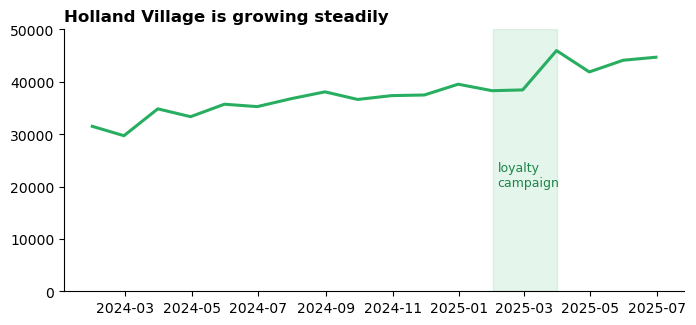

In [34]:
# 👉 `axvspan` shades a date range. Useful for campaigns, closures, and "before vs after".
fig, ax = plt.subplots(figsize=(8, 3.4))

ax.plot(monthly.index, monthly["OUT-04"], color="#27ae60", linewidth=2.2)
ax.axvspan(pd.Timestamp("2025-02-01"), pd.Timestamp("2025-03-31"), color="#27ae60", alpha=0.12)
ax.text(pd.Timestamp("2025-02-05"), 20000, "loyalty\ncampaign", fontsize=9, color="#1e8449")

ax.set_ylim(0, 50000)
ax.set_title("Holland Village is growing steadily", loc="left", weight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.show()


---

# ☕ Break — 10 minutes

**Where we are:** you can build a chart from scratch, control its axes, annotate it and save it.

**Next up:** Part 3 — seaborn, for the charts that involve a *distribution* rather than a single
number per group. This is where you stop hiding behind averages.


## Part 3: Seaborn for Statistical Graphics

**Learning outcome 3:** *Use Seaborn to produce statistical graphics appropriate for different data
types and questions.*

**Goal:** seaborn is matplotlib with statistics built in. It takes a DataFrame and column *names*,
does the grouping itself, and returns a matplotlib Axes you can still customise.

⏱️ ~45 min including Group Exercise 3


In [55]:
# 👉 `set_theme` sets fonts, colours and grid for everything after it. One line, whole notebook.
sns.set_theme(style="whitegrid", palette="colorblind")

# 👉 One row per till receipt, for the week of 16-22 June 2025. Averages hid this file until now.
print(tickets.shape)
tickets.head(3)


(4916, 8)


,txn_id,txn_datetime,outlet_id,daypart,category,items,amount_sgd,payment_method
0,T502810,2025-06-16 07:00:00,OUT-03,Morning,Pastry,1,4.84,PayNow
1,T502747,2025-06-16 07:00:00,OUT-03,Morning,Coffee,1,5.71,Card
2,T501542,2025-06-16 07:01:00,OUT-02,Morning,Coffee,1,6.81,PayNow


### 3.1: Distributions — what an average hides

Every outlet's average ticket sits between \$7.90 and \$8.80. That number is true and nearly useless:
it cannot tell you whether everyone spends about \$8, or whether most people spend \$6 and a minority
spend \$15.


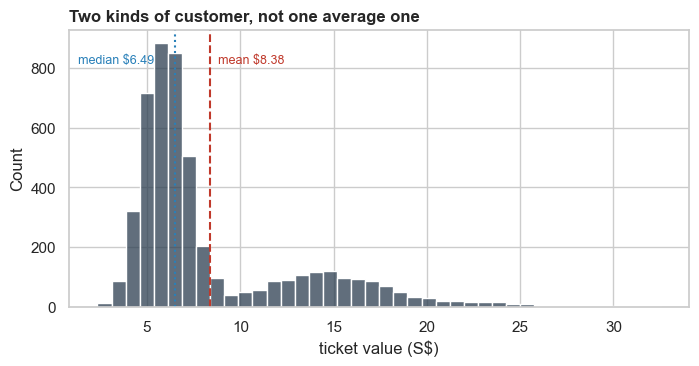

In [36]:
# 👉 `histplot` buckets the values and counts each bucket. `bins=40` = 40 buckets.
fig, ax = plt.subplots(figsize=(8, 3.6))

sns.histplot(data=tickets, x="amount_sgd", bins=40, color="#2c3e50", ax=ax)

# 👉 Mark the two summary numbers everyone reports, so you can see where they land.
mean_v, median_v = tickets["amount_sgd"].mean(), tickets["amount_sgd"].median()

ax.axvline(mean_v, color="#c0392b", linestyle="--", linewidth=1.5)
ax.text(mean_v + 0.4, ax.get_ylim()[1] * 0.88, f"mean ${mean_v:.2f}", color="#c0392b", fontsize=9)

ax.axvline(median_v, color="#2980b9", linestyle=":", linewidth=1.5)
ax.text(median_v - 5.2, ax.get_ylim()[1] * 0.88, f"median ${median_v:.2f}", color="#2980b9", fontsize=9)

ax.set_title("Two kinds of customer, not one average one", loc="left", weight="bold")
ax.set_xlabel("ticket value (S$)")
plt.show()


> **Read the shape.** There is a tall spike of small tickets around \$5–7 (a coffee, a pastry) and a
> long, flatter second hump around \$13–18 (a meal). The mean lands in the **dip between them** — a value
> that describes hardly any real customer. The median (\$6.49) is not much better on its own; it just
> sits inside the first hump and ignores the second.
>
> This is why "the average ticket is \$8.38" is a dangerous sentence. A promotion designed for an
> \$8 customer is aimed at somebody who does not exist. There are two businesses in this café —
> drinks and meals — and any decision has to pick one, or address both deliberately.


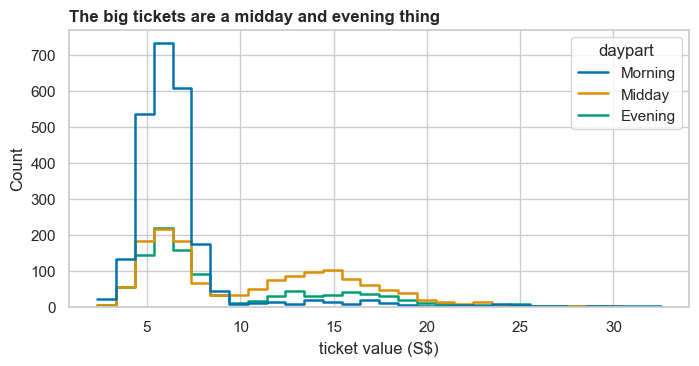

In [37]:
# 👉 `hue=` splits one chart by a category. `element="step"` keeps overlapping shapes readable.
fig, ax = plt.subplots(figsize=(8, 3.6))

sns.histplot(data=tickets, x="amount_sgd", hue="daypart", bins=30,
             element="step", fill=False, linewidth=1.8, ax=ax)

ax.set_title("The big tickets are a midday and evening thing", loc="left", weight="bold")
ax.set_xlabel("ticket value (S$)")
plt.show()


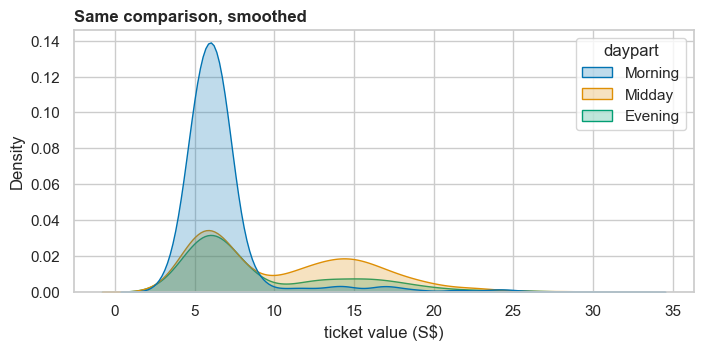

In [38]:
# 👉 A KDE is a smoothed version of a histogram -- no bin edges, so no bin-width arguments.
#    Good for comparing shapes; bad when you need exact counts.
fig, ax = plt.subplots(figsize=(8, 3.4))

sns.kdeplot(data=tickets, x="amount_sgd", hue="daypart", fill=True, alpha=0.25, ax=ax)

ax.set_title("Same comparison, smoothed", loc="left", weight="bold")
ax.set_xlabel("ticket value (S$)")
plt.show()


### 3.2: Categorical comparisons — box plots and bars

A box plot compresses a distribution into five numbers: minimum, lower quartile, **median**, upper
quartile, maximum, with outliers as dots. It is the right chart when you have several groups and need
to compare their *spread*, not just their centre.


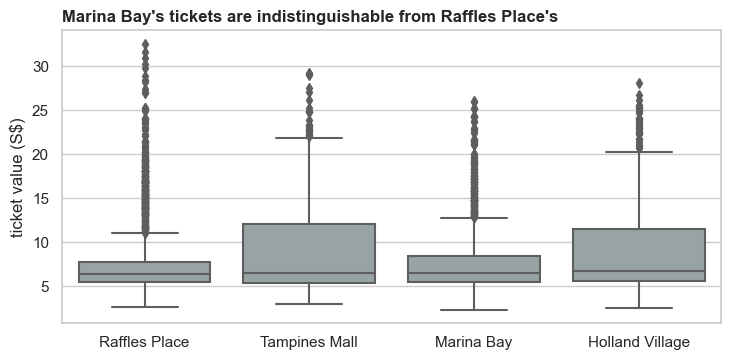

In [39]:
# 👉 One box per outlet. `order=` fixes the sequence, so it is a choice and not an accident.
fig, ax = plt.subplots(figsize=(8.5, 3.8))
# Box plots show the median, quartiles, and outliers. The box is the middle 50% of the data; the whiskers are 1.5× the interquartile range; dots beyond that are outliers.

order = ["OUT-01", "OUT-02", "OUT-03", "OUT-04"]
sns.boxplot(data=tickets[tickets["outlet_id"].isin(order)],
            x="outlet_id", y="amount_sgd", order=order, color="#95a5a6", ax=ax)

ax.set_xticklabels([names[o] for o in order])
ax.set_title("Marina Bay's tickets are indistinguishable from Raffles Place's",
             loc="left", weight="bold")
ax.set_xlabel("")
ax.set_ylabel("ticket value (S$)")
plt.show()


> **A finding can be an absence.** All four medians sit near \$6.40. Marina Bay's box is
> indistinguishable from Raffles Place's — its nearest twin, another CBD commuter café — which rules
> out an entire theory: Marina Bay's problem is *not* that its customers spend less per visit. They
> spend the same; there are simply fewer of them. One chart, and half the possible explanations are
> gone.
>
> **Read the other two boxes too.** Tampines Mall and Holland Village have *taller* boxes: same
> median, wider spread, because they sell more meals alongside the drinks. So the honest claim is the
> comparison that matters, not the sweeping one — "Marina Bay matches Raffles Place", not "all four
> are identical". A title is a claim, and the chart has to support the claim you put on it.


### 3.3: Violin plots and bar plots (Self-Study)

Violin plot and bar plots are the same data, different views. The violin shows the shape of the distribution; the bar shows the mean and a 95% confidence interval. Both are valid, but they answer different questions.

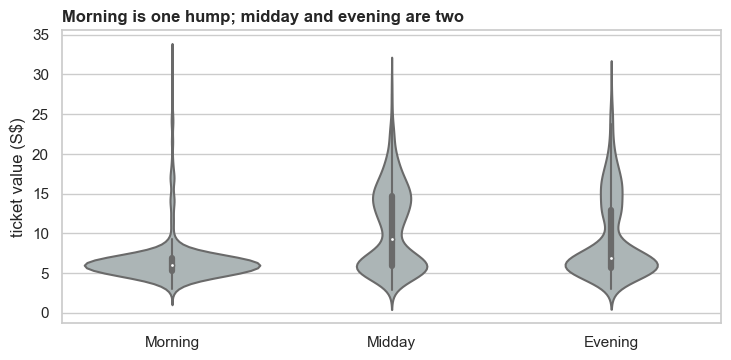

In [40]:
# 👉 A violin plot is a box plot plus the shape of the distribution -- it shows the two humps
#    that the box hides. More information, slightly more to explain to an audience.
fig, ax = plt.subplots(figsize=(8.5, 3.8))

sns.violinplot(data=tickets, x="daypart", y="amount_sgd",
               order=["Morning", "Midday", "Evening"], color="#aab7b8", ax=ax)

ax.set_title("Morning is one hump; midday and evening are two", loc="left", weight="bold")
ax.set_xlabel("")
ax.set_ylabel("ticket value (S$)")
plt.show()


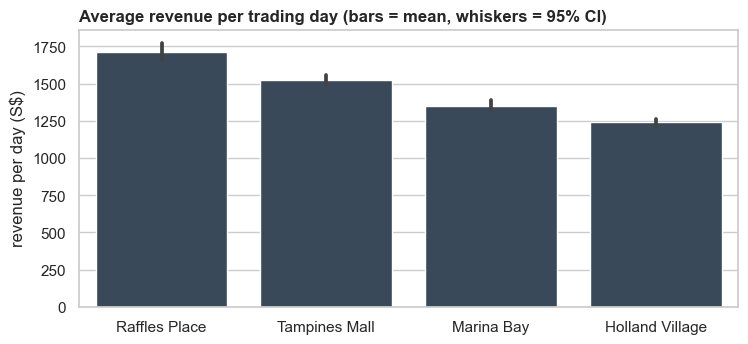

In [41]:
# 👉 `barplot` aggregates for you: by default it plots the MEAN and a 95% confidence interval (CI).
#    Know that, or you will report a mean while thinking you reported a total.
# 95% CI = mean ± 1.96 × (std / √n), where n is the number of observations in that group. More to b e explained later in module 3, but the key is that the whiskers are not the min and max.
daily_totals = sales.groupby(["date", "outlet_id"], as_index=False)["revenue_sgd"].sum()

fig, ax = plt.subplots(figsize=(8.5, 3.6))
sns.barplot(data=daily_totals[daily_totals["outlet_id"].isin(order)],
            x="outlet_id", y="revenue_sgd", order=order, errorbar=("ci", 95),
            color="#34495e", ax=ax)

ax.set_xticklabels([names[o] for o in order])
ax.set_title("Average revenue per trading day (bars = mean, whiskers = 95% CI)",
             loc="left", weight="bold")
ax.set_xlabel("")
ax.set_ylabel("revenue per day (S$)")
plt.show()


### 3.4: Relationships — scatter and regression (Self-Study)

A scatter plot answers "do these two move together?" — the visual version of the correlation you
computed in Lesson 1.9. Always look at the scatter *before* trusting a correlation number.


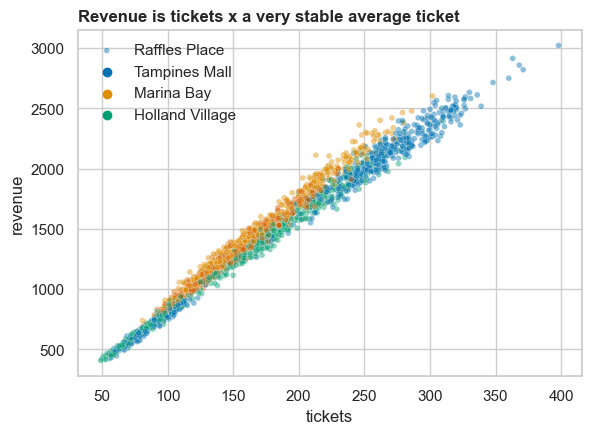

In [42]:
# 👉 One point per outlet per day: tickets sold against revenue taken.
fig, ax = plt.subplots(figsize=(6.5, 4.5))

daily = sales.groupby(["date", "outlet_id"], as_index=False).agg(
    revenue=("revenue_sgd", "sum"), tickets=("tickets", "sum")
)

sns.scatterplot(data=daily[daily["outlet_id"].isin(order)],
                x="tickets", y="revenue", hue="outlet_id", alpha=0.45, s=18, ax=ax)

ax.set_title("Revenue is tickets x a very stable average ticket", loc="left", weight="bold")
ax.legend(title="", labels=[names[o] for o in order], frameon=False)
plt.show()


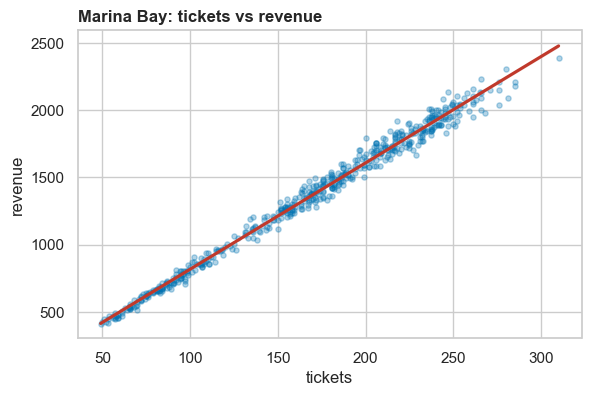

In [43]:
# 👉 `regplot` adds a fitted straight line and a shaded confidence band around it.
fig, ax = plt.subplots(figsize=(6.5, 4))

marina_daily = daily[daily["outlet_id"] == "OUT-03"]
sns.regplot(data=marina_daily, x="tickets", y="revenue",
            scatter_kws=dict(alpha=0.3, s=14), line_kws=dict(color="#c0392b"), ax=ax)

ax.set_title("Marina Bay: tickets vs revenue", loc="left", weight="bold")
plt.show()


> **Be careful what you conclude from that line.** It is nearly perfect, which sounds impressive and
> means almost nothing: revenue *is* tickets multiplied by the average ticket, so we have discovered
> arithmetic. A tight fit between two quantities that are definitionally linked is not a finding.
> Ask "could this have come out any other way?" before you put a regression line on a slide.


### 3.5: Heatmaps and small multiples (Self-Study)

A heatmap encodes value as colour on a grid. It suits exactly the shape that comes out of
`pivot_table`: two categorical axes and one number.


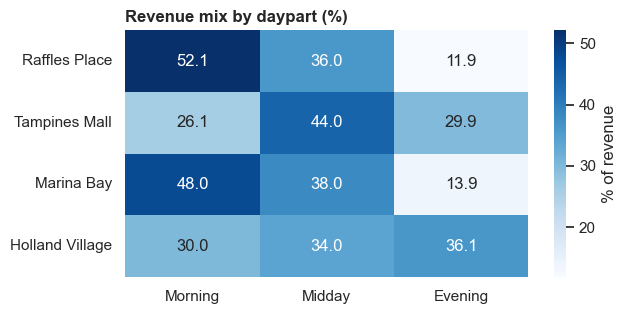

In [44]:
# 👉 The daypart mix from Part 1, as a heatmap. `annot=True` prints the numbers in the cells --
#    which is what makes a heatmap honest, because colour alone cannot be read precisely.
fig, ax = plt.subplots(figsize=(6.5, 3.2))

sns.heatmap(mix4, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "% of revenue"}, ax=ax)

ax.set_title("Revenue mix by daypart (%)", loc="left", weight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.show()


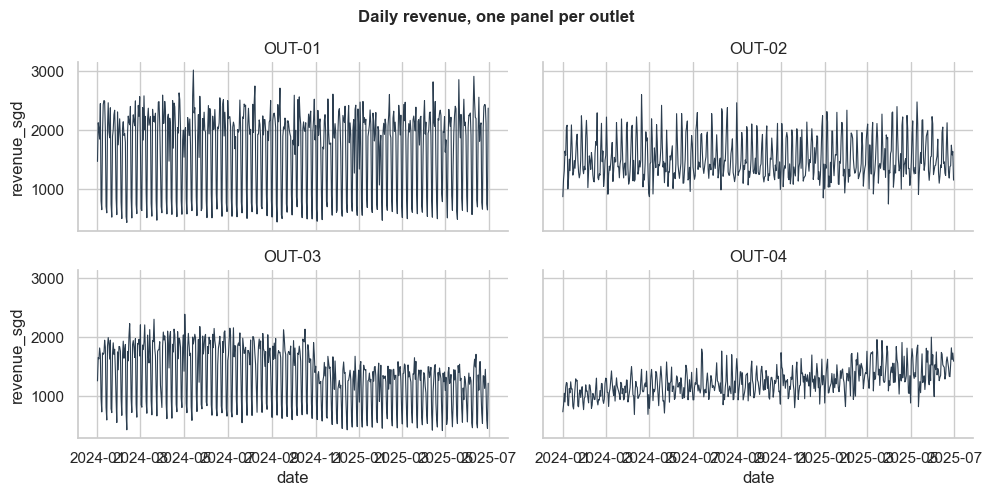

In [45]:
# 👉 `relplot` makes small multiples in one line: `col=` says which column to split panels by.
#    Note this returns a FacetGrid (a Figure-level object), not an Axes.
weekday_mean = (
    sales.groupby(["outlet_id", "date"], as_index=False)["revenue_sgd"].sum()
)
weekday_mean["weekday"] = weekday_mean["date"].dt.day_name().str[:3]

g = sns.relplot(
    data=weekday_mean[weekday_mean["outlet_id"].isin(order)],
    x="date", y="revenue_sgd", col="outlet_id", col_wrap=2,
    kind="line", height=2.4, aspect=2.1, color="#2c3e50", linewidth=0.8,
)

g.set_titles("{col_name}")
g.figure.suptitle("Daily revenue, one panel per outlet", y=1.03, fontsize=12, weight="bold")
plt.show()


> **Figure-level versus Axes-level.** `histplot`, `boxplot`, `scatterplot` draw onto an Axes you
> supply (`ax=ax`). `relplot`, `catplot`, `displot`, `pairplot` and `jointplot` create their **own**
> Figure and return a grid object — so `ax=` will raise an error, and you reach the underlying
> matplotlib objects through `g.figure` and `g.axes`. Two-thirds of confusing seaborn errors are
> this distinction.


### 🛠️ Group Exercise 3 — Statistical views (12 min)

Split (a), (b) and (c) across your group, then compare.

> **(a) Fill in the blanks** — ticket values by payment method:
> ```python
> fig, ax = plt.subplots(figsize=(8, 3.6))
> sns.boxplot(data=tickets, x="_______________", y="amount_sgd", ax=ax)
> ```
> *Expected:* the four methods look broadly similar — another useful absence of a finding.
>
> **(b) From scratch** — a heatmap of average ticket value with `outlet_id` down the side and
> `category` across the top. *Hint:* `pivot_table` first, then `sns.heatmap(..., annot=True, fmt=".2f")`.
>
> **(c) From scratch** — small multiples of the ticket-value distribution, one panel per daypart.
> *Hint:* `sns.displot(data=..., x="amount_sgd", col="daypart")`.
>
> **(d) Choose and justify** — you want to show that Marina Bay serves *fewer customers* rather than
> *cheaper customers*. Which single chart from this Part makes that point best, and what is the
> honest title for it?


---

## Part 4: Chart Choice & the One Slide

**Learning outcome 4:** *Select the right visualisation type for a given analytical context and
audience.*

**Goal:** the owner gets twenty seconds. Build the one figure that carries the decision.

⏱️ ~25 min


### 4.1: The message picks the chart (Self-Study)

Start from the sentence, not the chart type. This table is the whole of chart selection:

| The sentence you want them to leave with | Chart | Why it works |
|---|---|---|
| "X changed over time" | **line** | position over a continuous axis; the eye reads slope as change |
| "X is bigger than Y" | **bar** (from zero) | length on a shared baseline is the most accurately judged channel |
| "X is made up of these parts" | **stacked bar** or **treemap** | one whole, divided; pie only for 2–3 slices |
| "X and Y move together" | **scatter** | two positions at once reveals the joint pattern |
| "X varies more than you think" | **box**, **violin**, **histogram** | shows the spread an average conceals |
| "the pattern differs by group" | **small multiples** | shared axes make shapes comparable |
| "this cell is the hot spot" | **heatmap** | colour across two categorical axes |
| "one number matters" | **big number** with a line for context | do not chart a single figure; write it |

**And the audience decides the depth, not the truth:**

| Audience | Wants | So the chart is |
|---|---|---|
| Owner / executive | the decision | one panel, finding as the title, annotated cause |
| Manager | what to change | the driver broken out, comparison to target |
| Data team | the method | small multiples, distributions, uncertainty shown |

Same analysis every time. Only the framing changes. Presenting an executive the chart you built for
the data team is the single most common failure in this lesson — and it reads as "you did not think
about me".


### 4.2: The owner's slide

The message: **"The chain looks flat because Marina Bay's collapse is being hidden by Holland
Village's growth — and Marina Bay now pays double the rent share for the least productive hour."**

Two panels: the trend that carries the finding, and the cost that makes it a decision.


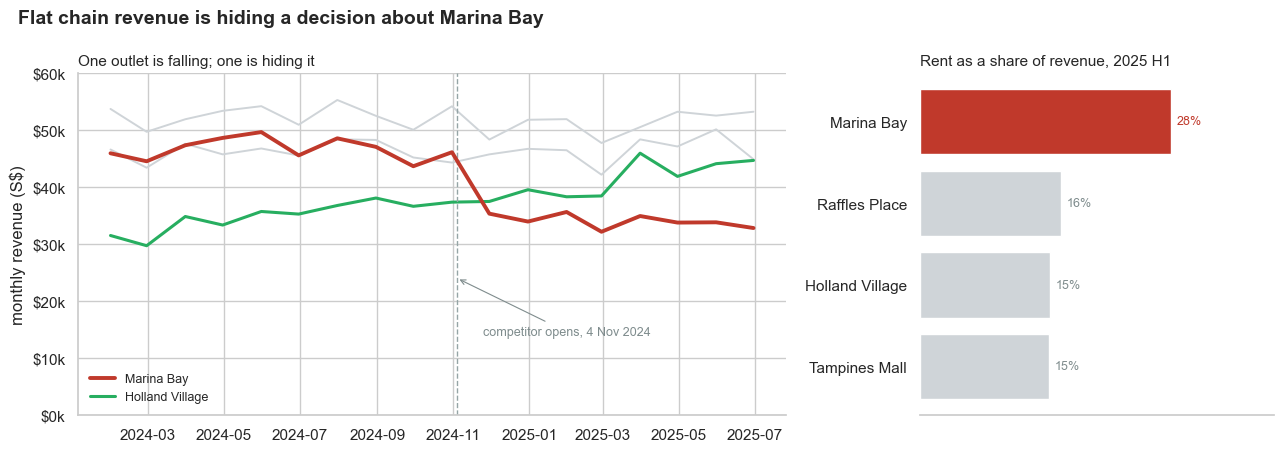

In [46]:
# 👉 One Figure, two Axes, sized so the trend gets more room than the bars.
#    `gridspec_kw` sets the relative widths.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [2, 1]})

# ---- left panel: the trend -------------------------------------------------
for col in ["OUT-01", "OUT-02", "OUT-03", "OUT-04"]:
    if col == "OUT-03":
        style = dict(color="#c0392b", linewidth=2.8, zorder=3, label="Marina Bay")
    elif col == "OUT-04":
        style = dict(color="#27ae60", linewidth=2.2, zorder=2, label="Holland Village")
    else:
        style = dict(color="#cfd4d8", linewidth=1.4, zorder=1)
    ax1.plot(monthly.index, monthly[col], **style)

ax1.axvline(pd.Timestamp("2024-11-04"), color="#95a5a6", linestyle="--", linewidth=1)
ax1.annotate("competitor opens, 4 Nov 2024",
             xy=(pd.Timestamp("2024-11-04"), 24000),
             xytext=(pd.Timestamp("2024-11-25"), 14000),
             fontsize=9, color="#7f8c8d",
             arrowprops=dict(arrowstyle="->", color="#7f8c8d", linewidth=0.8))

ax1.set_ylim(0, 60000)
ax1.set_ylabel("monthly revenue (S$)")
ax1.set_title("One outlet is falling; one is hiding it", loc="left", fontsize=11)
ax1.legend(frameon=False, loc="lower left", fontsize=9)
ax1.spines[["top", "right"]].set_visible(False)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v/1000:,.0f}k"))

# ---- right panel: the cost ------------------------------------------------
rent = decision["rent_pct_of_revenue"].dropna().sort_values()
bar_colours = ["#c0392b" if i == "OUT-03" else "#cfd4d8" for i in rent.index]

ax2.barh([names[i] for i in rent.index], rent.values, color=bar_colours)
for y, v in enumerate(rent.values):
    ax2.text(v + 0.6, y, f"{v:.0f}%", va="center", fontsize=9,
             color="#c0392b" if rent.index[y] == "OUT-03" else "#7f8c8d")

ax2.set_xlim(0, 40)
ax2.set_title("Rent as a share of revenue, 2025 H1", loc="left", fontsize=11)
ax2.spines[["top", "right", "left"]].set_visible(False)
ax2.set_xticks([])
ax2.grid(False)

# ---- the message, as the Figure title ------------------------------------
fig.suptitle("Flat chain revenue is hiding a decision about Marina Bay",
             fontsize=14, weight="bold", x=0.02, ha="left")

plt.tight_layout()
fig.savefig("../visualisations/owner_slide.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.3: The twenty seconds of script that goes with it

A chart does not present itself. Three acts, one sentence each:

> **Act 1 — context.** "Chain revenue has been flat for two quarters, so nothing looks urgent."
>
> **Act 2 — the finding.** "It is flat because these two cancel out: Marina Bay is down 28% year on
> year, Holland Village is up 27%. Marina Bay's fall happened in one week last November, when a
> competitor opened next door — and it has been flat at the new level ever since."
>
> **Act 3 — the decision.** "Marina Bay now spends 28% of its revenue on rent against 15% everywhere
> else, and earns \$20 per staff hour against \$25--27. Before you sign the lease, the question is whether
> that November step can be reversed. If not, the rent is the wrong price for this outlet now."

**Notice what the script does not do.** It does not say "close Marina Bay". Your job was to make the
comparison unavoidable; the decision is hers. That distinction is what separates an analyst from
someone with an agenda and a chart.


## 👉 One last check on your own work. Run this over any chart before you send it.

    ☑️ Does the title state the finding, not the metric?
    ☑️ Do bar charts start at zero?
    ☑️ Is colour carrying meaning, not decoration?
    ☑️ Are there fewer than about five things demanding attention?
    ☑️ Do axis labels include units?
    ☑️ Would this be readable printed in black and white?
    ☑️ If the reader saw only this chart, with no voiceover, would they get the message?

## 🎯 Wrap-Up

1. **The chart is chosen by the message.** Write the sentence first; the chart type follows.
2. **Perception is a budget.** Colour is your loudest tool — spend it on one thing, and grey the rest.
3. **Bars start at zero.** Lines do not have to. Length is compared; position is read for change.
4. **The title is the finding.** "Monthly Revenue" tells no one anything. Use the sentence.
5. **Annotate the cause on the chart.** A chart that travels without you must explain itself.
6. **Distributions before averages.** An $8.38 mean ticket described a customer who does not exist.
7. **An absence is a finding.** Identical box plots ruled out "customers spend less" in one chart.
8. **Small multiples need `sharey=True`,** or they mislead by accident.
9. **Your job is to make the comparison unavoidable** — not to make the decision.

**Next Steps:**
- Complete the [Assignment](./assignment.md) — critique, redesign, and build your own one slide.
- Module 1 is complete: you can now take a messy file (1.8), find the pattern in it (1.9), and make
  someone act on it (1.10). That is the whole job.


### 📦 Appendix — self-study

In `reference.md`, with worked examples:

- **Colour theory and accessibility:** qualitative vs sequential vs diverging palettes; colour-blind-safe
  choices; why `viridis` exists.
- **Gestalt principles** and the research behind pre-attentive processing.
- **`pairplot`, `jointplot`, `FacetGrid`** — the rest of seaborn's figure-level API.
- **Styles and rcParams:** `sns.set_theme`, `plt.rcParams`, house-style defaults.
- **Saving for print vs screen:** dpi, vector versus raster, `bbox_inches`.
- **Interactive charts:** where plotly and altair fit, and when they are worth the dependency.


---

## ✅ Sample Solutions — Group Exercises 1, 2 and 3

Work the exercises first. These are *sample* answers, not the only correct ones: for the code parts
there are several defensible ways to get the same chart, and for the discussion parts what matters is
whether your reasoning names a pillar, not whether your wording matches this.

**Run order:** these cells depend on `monthly`, `by_daypart`, `mix4`, `names`, `decision`, `tickets`,
`sales`, `outlets` and `FuncFormatter` from earlier in the notebook. Run the notebook top to bottom
first, or re-run the Setup cells plus section 2.3.

Read each solution against the checklist above: does the title state the finding, do the bars start at
zero, is colour carrying meaning?

### Group Exercise 1 — sample solutions

**(a) / (b) Critique of the names-only chart** — five problems, one pillar each:

| # | Problem | Pillar | Fix |
|---|---|---|---|
| 1 | No title, so no message. The reader has to guess what they are meant to notice. | Storytelling | title that states the finding |
| 2 | Absolute dollars, so the two biggest outlets dominate and the *mix* — the actual question — is invisible. | Design | convert each row to % of itself |
| 3 | The closed pop-up kiosk (OUT-05) is still there, spending attention on an outlet nobody can act on. | Perception | drop it |
| 4 | Fifteen bars in five groups, three colours, and no ordering — well past the roughly-four-things budget. | Perception | stacked bars, one row per outlet |
| 5 | No axis label or units. Dollars? Thousands? Tickets? | Design | label the axis with units |

Two more worth naming if your group found them: the x labels rotate to vertical (readability, Design),
and the legend order Morning/Midday/Evening is inherited from the column order rather than chosen —
here it happens to be the right chronological order, which is luck, not judgement (Design).

**How to grade your own list:** the point is not to find all five. It is that every problem you found
maps onto exactly one pillar. If it maps onto none, it is probably a preference, not a problem.

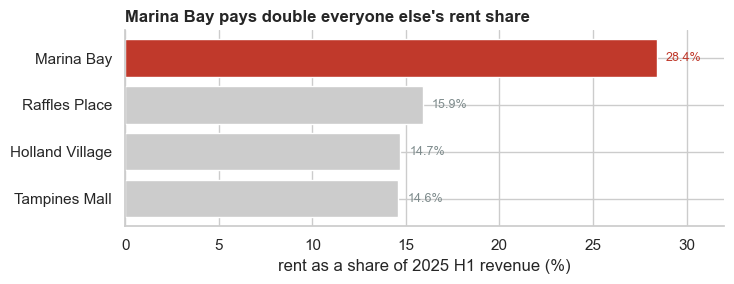

In [47]:
# 👉 1(c) the blanks filled in. Three of them:
#      "______"  -> "OUT-03"     (Marina Bay's code -- the highlight)
#      color=____ -> colours      (the list built on the line above)
#      set_ylim   -> WRONG METHOD. For barh, the value runs along x, so it is set_xlim(0, ...).
r = decision["rent_pct_of_revenue"].dropna().sort_values()
colours = ["#c0392b" if i == "OUT-03" else "#cccccc" for i in r.index]

fig, ax = plt.subplots(figsize=(7.5, 3))
ax.barh([names[i] for i in r.index], r.values, color=colours)

ax.set_xlim(0, 32)                    # 👈 the zero-baseline rule, on the axis that carries the value

# 👉 Direct labels beat a gridline the reader has to trace back to an axis.
for y, v in enumerate(r.values):
    ax.text(v + 0.5, y, f"{v:.1f}%", va="center", fontsize=9,
            color="#c0392b" if r.index[y] == "OUT-03" else "#7f8c8d")

ax.set_xlabel("rent as a share of 2025 H1 revenue (%)")
ax.set_title("Marina Bay pays double everyone else's rent share", loc="left", weight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# 👉 Expected, and confirmed: Tampines 14.6%, Holland Village 14.7%, Raffles Place 15.9%,
#    Marina Bay 28.4% -- about 1.8x the others, which is what "roughly twice" meant.

**(d) Argue for a truncated axis on a bar chart — sample answer**

**The defensible case, in one sentence:** when the *audience already knows the baseline is not zero*,
the differences are genuinely small but genuinely important, **and the truncation is declared on the
chart itself**.

Three conditions, all required:

1. **The quantity has a meaningful non-zero floor.** Body temperature, exam pass rates, an
   ingredient's purity, a service level that must sit above 99%. Zero is not a possible or relevant
   value, so anchoring there wastes the whole axis showing a region nothing will ever occupy.
2. **The small difference is the decision.** A move from 99.95% to 99.5% uptime is a serious
   regression that a zero-based bar chart makes literally invisible.
3. **You say so, visibly.** Label the axis start, or break the bars with a visible axis break marker,
   or write "note: axis starts at 95%" beside the title. The lie is not the truncation — it is the
   *undeclared* truncation.

**The stronger counter-argument:** if all three conditions hold, you probably wanted a different chart
anyway. A **line chart** (position, read for change), a **dot plot** (position, no length to
misread), or a **deviation-from-target bar** (zero-based, where zero *is* the target) all show the
small difference honestly without breaking the length-encodes-value contract.

**So the honest resolution:** truncating a bar axis is defensible but almost never optimal — the
existence of a defence is not a reason to use it. Our café data fails condition 1 outright: revenue
of zero is entirely possible, which is exactly the point of the Marina Bay decision.

### Group Exercise 2 — sample solutions

**(a)** was worked in the lesson (the `axvspan` campaign shading). Sample answers for (b), (c) and (d)
follow. Note that `FuncFormatter` was imported back in section 2.3 — if you restarted the kernel, run
that cell first.

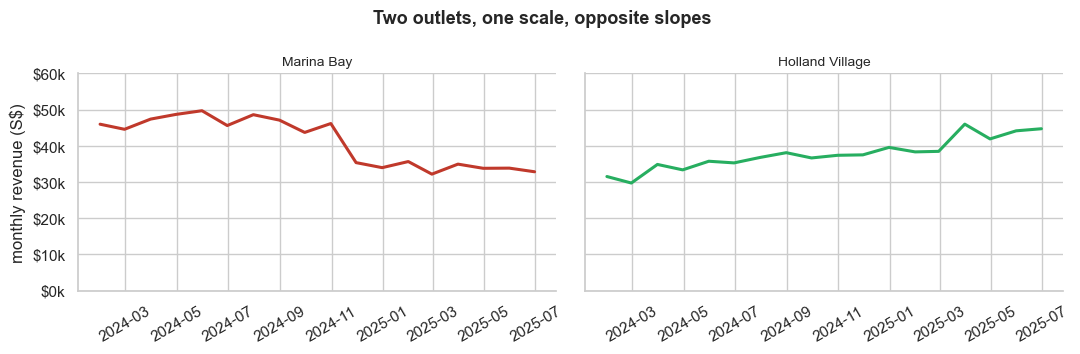

In [48]:
# 👉 2(b) the blanks: sharey=True, and monthly[outlet].
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)

for ax, outlet in zip(axes, ["OUT-03", "OUT-04"]):
    ax.plot(monthly.index, monthly[outlet], linewidth=2.2,
            color="#c0392b" if outlet == "OUT-03" else "#27ae60")
    ax.set_title(names[outlet], fontsize=10)
    ax.set_ylim(0, 60000)                      # the same limit on both, belt and braces
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", labelrotation=30)

axes[0].set_ylabel("monthly revenue (S$)")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v/1000:,.0f}k"))

fig.suptitle("Two outlets, one scale, opposite slopes", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

# 👉 Try it with sharey=False and compare: the two panels then look like the same story twice,
#    because matplotlib rescales each one to its own data. That is the accidental lie from 2.2.

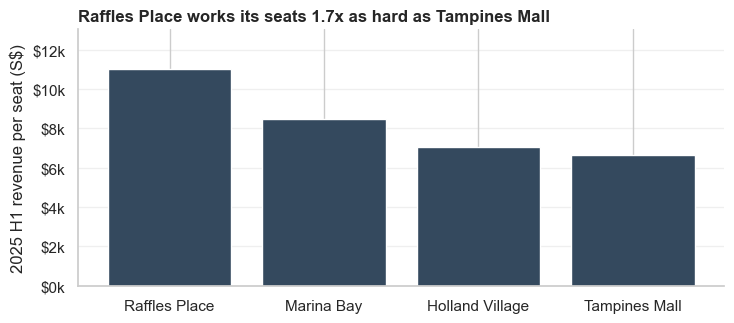

outlet_id
OUT-01    11048.0
OUT-03     8464.0
OUT-04     7040.0
OUT-02     6649.0
dtype: float64

In [49]:
# 👉 2(c) from scratch: revenue per seat, 2025 H1, four permanent outlets.
#    Step 1 -- the number. Filter to H1 2025, total the revenue, divide by seats.
h1_sales = sales[(sales["date"] >= "2025-01-01") & (sales["date"] <= "2025-06-30")]
rev_h1 = h1_sales.groupby("outlet_id")["revenue_sgd"].sum()
seats = outlets.set_index("outlet_id")["seats"]

per_seat = (rev_h1 / seats).loc[["OUT-01", "OUT-02", "OUT-03", "OUT-04"]].sort_values(ascending=False)

# 👉 Step 2 -- the chart. Zero baseline (it is a bar), formatted axis, finding as the title.
fig, ax = plt.subplots(figsize=(7.5, 3.4))

ax.bar([names[i] for i in per_seat.index], per_seat.values, color="#34495e")

ax.set_ylim(0, per_seat.max() * 1.18)                                   # bars start at zero
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v/1000:,.0f}k"))
ax.set_ylabel("2025 H1 revenue per seat (S$)")
ax.set_title("Raffles Place works its seats 1.7x as hard as Tampines Mall",
             loc="left", weight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

per_seat.round(0)

> **Careful with the title you just wrote.** Revenue per seat ranks Raffles Place \$11.0k, Marina Bay
> \$8.5k, Holland Village \$7.0k, Tampines Mall \$6.6k — so *Marina Bay is not the worst on this
> metric*. If you had assumed the finding before computing it and titled the chart "Marina Bay wastes
> its seats", the chart would have contradicted you in front of the owner.
>
> This is the honest version of chart selection: the metric decides the story, not the other way
> round. Seats are a proxy for floor area, and mall outlets buy space cheaply, so per-seat revenue is
> the wrong measure of Marina Bay's problem. **Rent as a share of revenue** (28% vs ~15%) is the right
> one — and that is why the owner's slide in Part 4 uses that and not this.

**(d) Twelve outlets over eighteen months — sample answer**

**Twelve small panels, with one exception.**

| Pillar | Why small multiples win |
|---|---|
| **Perception** | working memory holds about four things. Twelve lines need twelve legend lookups, and any line you want to trace is crossed by eleven others — "spaghetti". Twelve panels ask the eye to compare *shapes*, which it does well. |
| **Design** | one shared y-scale (`sharey=True`) keeps the comparison honest; twelve colours that are distinguishable *and* colour-blind-safe do not exist. |
| **Storytelling** | the message is "which of these behaves differently", and an odd shape in a grid of twelve is found instantly. |

**The exception:** if the message is about *one* outlet — "Marina Bay is the only one falling" — go
back to one Axes and use the grey-plus-one-red treatment from Part 1. That is not twelve lines, it is
one line plus context.

**Rule of thumb:** up to about 4 series on one Axes; above that, either small multiples (comparing
all of them) or highlight-plus-grey (one of them is the story).

### Group Exercise 3 — sample solutions

All four medians land between \$6.43 and \$6.55, so (a) is another **useful absence of a finding**:
how somebody pays says nothing about how much they spend.

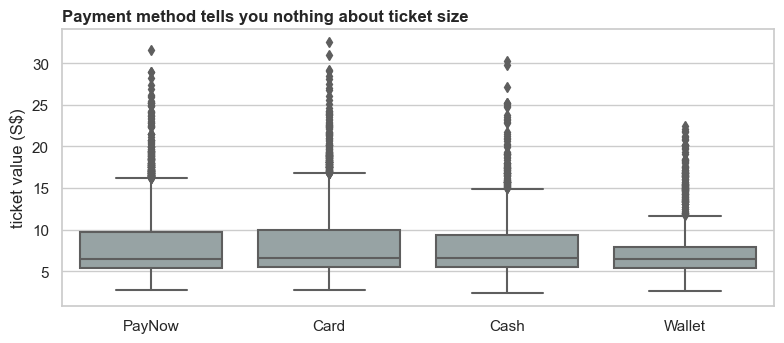

,count,median,mean
payment_method,,,
Card,1907,6.53,8.49
Cash,688,6.55,8.42
PayNow,1712,6.43,8.42
Wallet,609,6.48,7.90


In [50]:
# 👉 3(a) the blank was the column name: "payment_method".
fig, ax = plt.subplots(figsize=(8, 3.6))

sns.boxplot(data=tickets, x="payment_method", y="amount_sgd", color="#95a5a6", ax=ax)

ax.set_title("Payment method tells you nothing about ticket size", loc="left", weight="bold")
ax.set_xlabel("")
ax.set_ylabel("ticket value (S$)")
plt.tight_layout()
plt.show()

# 👉 The numbers behind the picture -- always check the chart is telling the truth.
tickets.groupby("payment_method")["amount_sgd"].agg(["count", "median", "mean"]).round(2)

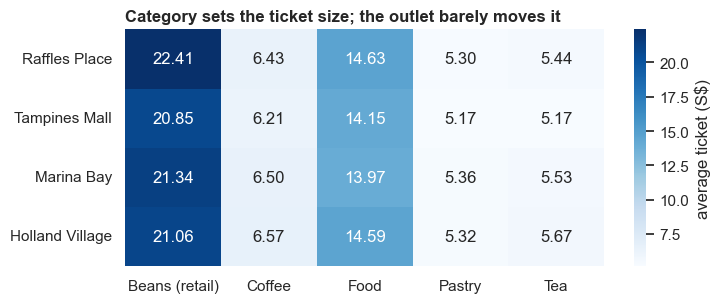

In [51]:
# 👉 3(b) from scratch: average ticket value, outlet down the side, category across the top.
#    Step 1 -- pivot_table gives exactly the shape a heatmap wants: two categorical axes, one number.
avg_ticket = tickets.pivot_table(
    index="outlet_id", columns="category", values="amount_sgd", aggfunc="mean"
)
avg_ticket.index = [names[i] for i in avg_ticket.index]   # names, not codes

fig, ax = plt.subplots(figsize=(7.5, 3.2))

# 👉 Step 2 -- `annot=True` prints the value in each cell. A heatmap without numbers asks the reader
#    to decode colour, which is the least accurate channel there is.
sns.heatmap(avg_ticket, annot=True, fmt=".2f", cmap="Blues",
            cbar_kws={"label": "average ticket (S$)"}, ax=ax)

ax.set_title("Category sets the ticket size; the outlet barely moves it", loc="left", weight="bold")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.show()

# 👉 Read it by ROW and by COLUMN and you get two different findings:
#    - across columns: beans (~$21) and food (~$14) are a different business from coffee/tea/pastry (~$5-7)
#    - down any column: the four outlets agree to within about 30 cents
#    So the variation is in WHAT is sold, not WHERE. That is the same conclusion as the box plot,
#    reached from a different direction -- which is how you know it is real.

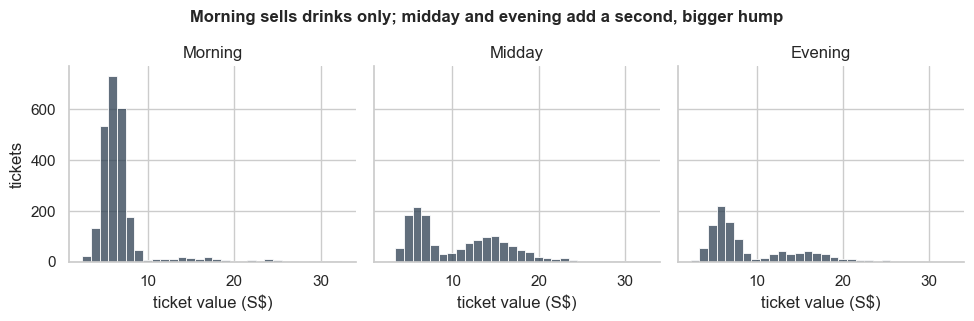

In [52]:
# 👉 3(c) from scratch: small multiples of the ticket-value distribution, one panel per daypart.
#    `displot` is FIGURE-level -- it makes its own Figure, so there is no `ax=` here.
#    `col_order` fixes the sequence (morning, midday, evening) instead of leaving it to chance.
g = sns.displot(
    data=tickets, x="amount_sgd", col="daypart",
    col_order=["Morning", "Midday", "Evening"],
    bins=30, height=3, aspect=1.1, color="#2c3e50",
)

# 👉 Reach the matplotlib objects through the grid: `g.figure` and `g.axes`.
g.set_titles("{col_name}")
g.set_axis_labels("ticket value (S$)", "tickets")
g.figure.suptitle("Morning sells drinks only; midday and evening add a second, bigger hump",
                  y=1.06, fontsize=12, weight="bold")
plt.show()

# 👉 The same comparison from 3.1, but split rather than overlaid. Overlaid (hue=) is better for
#    reading the differences; split panels are better when each shape needs to be read on its own.

**(d) Choose and justify — sample answer**

**The chart: the box plot of ticket value by outlet (section 3.2).** Paired with the daily-tickets
number, it is the one chart that separates the two explanations.

The claim "fewer customers, not cheaper customers" is really two claims, and the box plot settles the
second one on its own: all four medians sit near \$6.40–6.70, and Marina Bay's box is
indistinguishable from Raffles Place's — its nearest twin. So *cheaper customers* is ruled out. What
is left is volume: Marina Bay averages about 139 tickets a trading day in 2025 H1 against Raffles
Place's 215.

**Honest title:** *"Marina Bay's customers spend the same as Raffles Place's — there are just 35% fewer of them"*

**Why not the alternatives:**
- A **bar chart of average ticket** would show four near-identical bars. True, but it looks like a
  chart with no finding, and it hides the spread that makes "indistinguishable" credible.
- A **line chart of revenue** shows the fall but not *which* of the two causes produced it — that is
  the exact question being asked.
- A **violin plot** would work too, and shows more; the box plot wins on a slide because it needs no
  explanation. Use the violin for the data team, the box for the owner.

**The general move:** when two explanations both fit the headline number, pick the chart that kills
one of them. A chart that eliminates a hypothesis is worth more than a chart that restates the total.